# Running Palace Simulations

[Palace](https://awslabs.github.io/palace/) is an open-source 3D electromagnetic simulator supporting eigenmode, driven (S-parameter), and electrostatic simulations. This notebook demonstrates using the `gsim.palace` API to run a driven simulation on a CPW (coplanar waveguide) structure.

**Requirements:**

- IHP PDK: `uv pip install ihp-gdsfactory`
- [GDSFactory+](https://gdsfactory.com) account for cloud simulation

### Load a pcell from IHP PDK

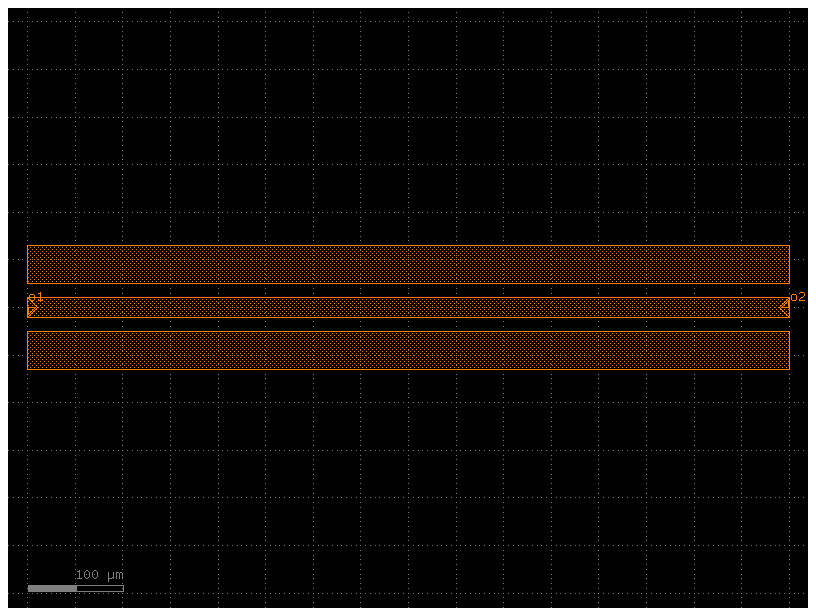

In [1]:
import gdsfactory as gf
from ihp import LAYER, PDK

PDK.activate()


@gf.cell
def gsg_electrode(
    length: float = 800,
    s_width: float = 20,
    g_width: float = 40,
    gap_width: float = 15,
    layer=LAYER.TopMetal2drawing,
) -> gf.Component:
    """
    Create a GSG (Ground-Signal-Ground) electrode.

    Args:
        length: horizontal length of the electrodes
        s_width: width of the signal (center) electrode
        g_width: width of the ground electrodes
        gap_width: gap between signal and ground electrodes
        layer: layer for the metal
    """
    c = gf.Component()

    # Top ground electrode
    r1 = c << gf.c.rectangle((length, g_width), centered=True, layer=layer)
    r1.move((0, (g_width + s_width) / 2 + gap_width))

    # Center signal electrode
    _r2 = c << gf.c.rectangle((length, s_width), centered=True, layer=layer)

    # Bottom ground electrode
    r3 = c << gf.c.rectangle((length, g_width), centered=True, layer=layer)
    r3.move((0, -(g_width + s_width) / 2 - gap_width))

    # Add ports at the signal center (one per side)
    # The CPW port API computes the gap element surfaces from s_width and gap_width
    c.add_port(
        name="o1",
        center=(-length / 2, 0),
        width=s_width,
        orientation=0,
        port_type="electrical",
        layer=layer,
    )

    c.add_port(
        name="o2",
        center=(length / 2, 0),
        width=s_width,
        orientation=180,
        port_type="electrical",
        layer=layer,
    )

    return c


c = gsg_electrode()
cc = c.copy()
cc.draw_ports()
cc

### Configure and run simulation with DrivenSim

In [2]:
from gsim.palace import DrivenSim

# Create simulation object
sim = DrivenSim()

# Set output directory
sim.set_output_dir("./palace-sim-cpw")

# Set the component geometry
sim.set_geometry(c)

# Configure layer stack from active PDK
sim.set_stack(substrate_thickness=2.0, air_above=300.0)

# Configure left CPW port (single port at signal center)
sim.add_cpw_port("o1", layer="topmetal2", s_width=20, gap_width=15)

# Configure right CPW port (single port at signal center)
sim.add_cpw_port("o2", layer="topmetal2", s_width=20, gap_width=15)

# Configure driven simulation (frequency sweep for S-parameters)
sim.set_driven(fmin=1e9, fmax=100e9, num_points=300)

# Validate configuration
print(sim.validate_config())

Validation: PASSED


In [3]:
# Generate mesh with planar conductors (presets: "coarse", "default", "fine")
sim.mesh(preset="default", planar_conductors=False)

Mesh Summary
Dimensions: 900.0 x 230.0 x 318.3 µm
Nodes:      9,567
Elements:   73,729
Tetrahedra: 53,815
Edge length: 0.05 - 300.00 µm
Quality:    0.454 (min: 0.001)
SICN:       0.500 (all valid)
----------------------------------------
Volumes (3):
  - SiO2 [1]
  - passive [2]
  - air [3]
Surfaces (11):
  - topmetal2_xy [4]
  - topmetal2_z [5]
  - P1_E0 [6]
  - P1_E1 [7]
  - P2_E0 [8]
  - P2_E1 [9]
  - SiO2__None [10]
  - SiO2__passive [11]
  - passive__None [12]
  - air__passive [13]
  - air__None [14]
----------------------------------------
Mesh:   palace-sim-cpw/palace.msh

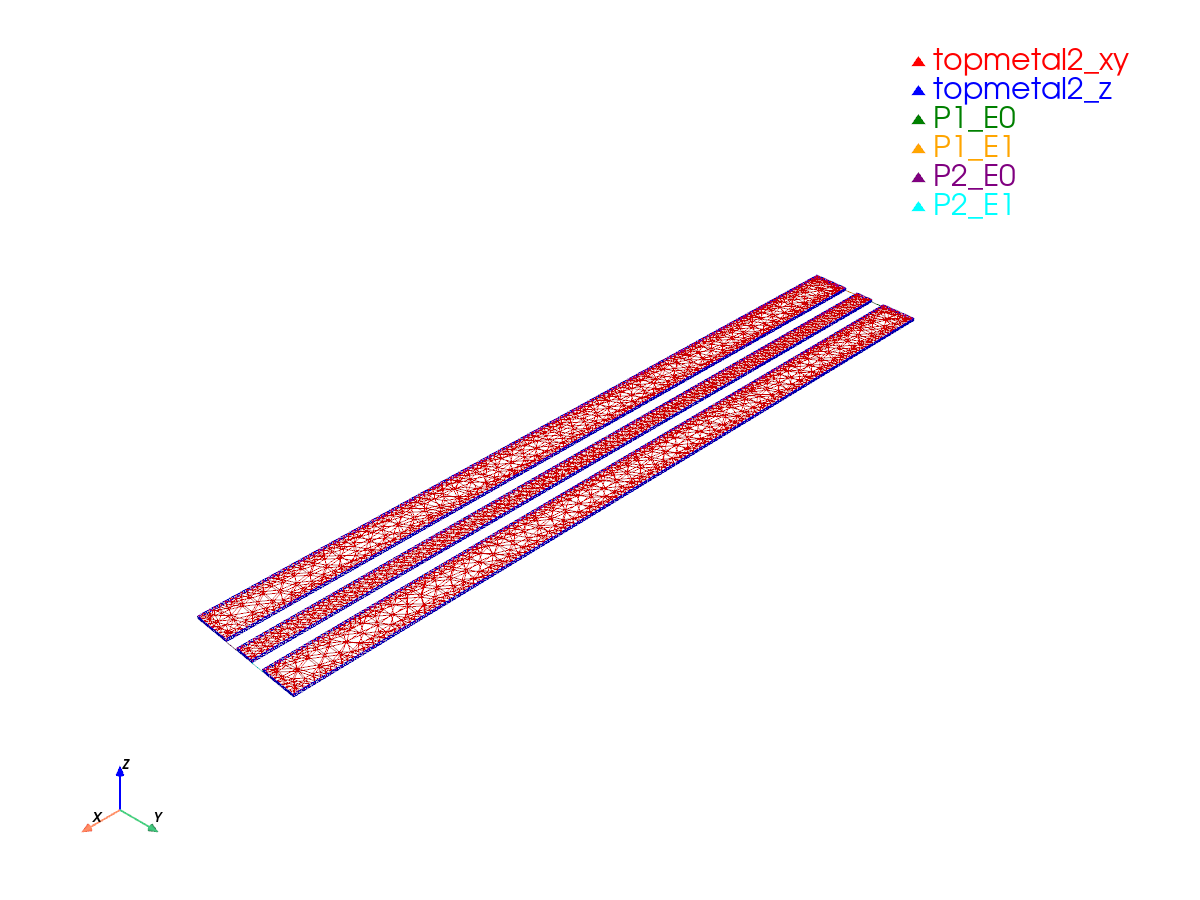

In [4]:
sim.plot_mesh(show_groups=["metal", "P"])

### Run simulation on cloud

In [5]:
# Run simulation on GDSFactory+ cloud
results = sim.run()

  palace-e41b37ac  completed  7m 25s


Extracting results.tar.gz...
Downloaded 11 files to sim-data-palace-e41b37ac


In [6]:
results.plot_plotly()